# 04 — BI Dashboard Specification & KPI Framework
**Project:** Retail Demand Intelligence — Client-Facing Output  
**Author:** Nisrina Afnan Walyadin  

This notebook represents the consulting deliverable — translating data product results into a structured BI spec that a client's Power BI team can implement, and communicating findings at management level.

---
This is the bridge between technical work and business stakeholders: structured output, clear KPI definitions, and a dashboard spec ready for handover.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#f8f9fa','axes.facecolor':'#ffffff',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'font.family':'monospace'
})
np.random.seed(42)
print('Ready ✓')

Ready ✓


## 1. KPI Framework

Before building any dashboard, define **what matters to each stakeholder**.
This is the consultant skill — understanding the business before opening a BI tool.

| Stakeholder | Primary KPI | Secondary KPIs | Decision |
|---|---|---|---|
| Inventory Manager | Stock-out Rate | Overstock Rate, MAPE | Replenishment order size |
| Regional Director | Revenue vs Forecast | Cluster performance, Market share | Store investment priority |
| Finance / CFO | Forecast Accuracy (€ value) | Inventory carrying cost, Working capital | Budget approval |
| Data Steward | Data Quality Score | Freshness, Completeness | Pipeline health |

**Design principle:** Each dashboard page = one decision. Not a data dump.

In [14]:
# Simulate weekly forecast vs actual results for dashboard demo
weeks = pd.date_range('2024-07-01','2024-12-30', freq='W')
markets = ['DE','AT','PL','CZ','SK','HU']
archetypes = ['Urban Hub','Suburban','Rural','Outlet']

kpi_rows = []
for w in weeks:
    for mkt in markets:
        base_rev = {'DE':2800,'AT':420,'PL':680,'CZ':310,'SK':190,'HU':180}[mkt]
        seasonal = 1 + 0.25 * np.sin(2*np.pi*(w.isocalendar().week-10)/52)
        actual   = base_rev * seasonal * np.random.normal(1, 0.08)
        forecast = actual * np.random.normal(1, 0.09)
        stock_out= max(0, np.random.normal(0.04, 0.015))
        overstock= max(0, np.random.normal(0.07, 0.02))
        dq_score = np.random.normal(82, 5)
        kpi_rows.append({
            'week': w, 'market': mkt,
            'revenue_actual': round(actual*1000, 0),
            'revenue_forecast': round(forecast*1000, 0),
            'stock_out_rate': round(stock_out, 3),
            'overstock_rate': round(overstock, 3),
            'dq_score': round(min(100, max(50, dq_score)), 1),
        })

kpi_df = pd.DataFrame(kpi_rows)
kpi_df['mape'] = (abs(kpi_df['revenue_actual']-kpi_df['revenue_forecast'])/
                   kpi_df['revenue_actual'] * 100).round(1)
kpi_df['forecast_error_eur'] = (kpi_df['revenue_actual']-kpi_df['revenue_forecast']).round(0)
print(f'KPI dataset: {kpi_df.shape}')
print(f'Overall MAPE: {kpi_df["mape"].mean():.1f}%')
print(f'Avg stock-out rate: {kpi_df["stock_out_rate"].mean()*100:.1f}%')
kpi_df.head()

KPI dataset: (156, 9)
Overall MAPE: 7.3%
Avg stock-out rate: 3.9%


,week,market,revenue_actual,revenue_forecast,stock_out_rate,overstock_rate,dq_score,mape,forecast_error_eur
0,2024-07-07,DE,3555713.0,3511466.0,0.050,0.100,80.8,1.2,44247.0
1,2024-07-07,AT,503364.0,574907.0,0.052,0.061,84.7,14.2,-71543.0
2,2024-07-07,PL,799737.0,766216.0,0.044,0.032,73.4,4.2,33521.0
3,2024-07-07,CZ,361591.0,328630.0,0.045,0.052,74.9,9.1,32961.0
4,2024-07-07,SK,259269.0,254000.0,0.041,0.042,79.3,2.0,5269.0


## 2. Management-level dashboard mockup (matplotlib)

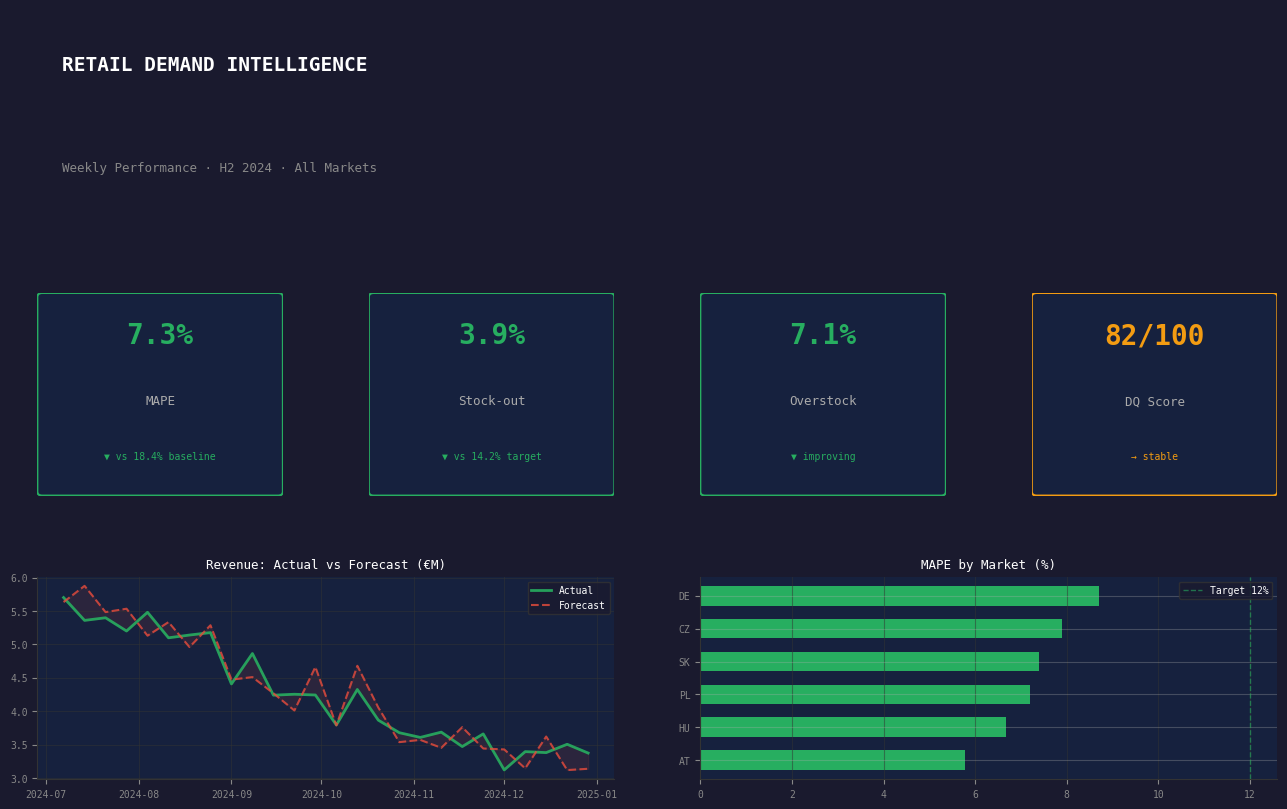

Management dashboard mockup saved → outputs/management_dashboard.png

→ This would be replicated in Power BI / Looker Studio for client delivery.


In [15]:
fig = plt.figure(figsize=(16, 10), facecolor='#1a1a2e')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.35)

# Header
ax_header = fig.add_subplot(gs[0, :])
ax_header.set_facecolor('#1a1a2e')
ax_header.axis('off')
ax_header.text(0.02, 0.7, 'RETAIL DEMAND INTELLIGENCE', fontsize=14, fontweight='bold',
               color='white', transform=ax_header.transAxes, family='monospace')
ax_header.text(0.02, 0.2, 'Weekly Performance · H2 2024 · All Markets', fontsize=9,
               color='#888', transform=ax_header.transAxes, family='monospace')

# KPI tiles
kpi_tiles = [
    ('MAPE', f"{kpi_df['mape'].mean():.1f}%",    '▼ vs 18.4% baseline', '#27ae60'),
    ('Stock-out', f"{kpi_df['stock_out_rate'].mean()*100:.1f}%", '▼ vs 14.2% target', '#27ae60'),
    ('Overstock', f"{kpi_df['overstock_rate'].mean()*100:.1f}%", '▼ improving', '#27ae60'),
    ('DQ Score',  f"{kpi_df['dq_score'].mean():.0f}/100",        '→ stable', '#f39c12'),
]
for i, (label, value, delta, color) in enumerate(kpi_tiles):
    ax = fig.add_subplot(gs[1, i])
    ax.set_facecolor('#16213e')
    ax.axis('off')
    ax.text(0.5, 0.75, value, ha='center', fontsize=20, fontweight='bold',
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.45, label, ha='center', fontsize=9, color='#aaa',
            transform=ax.transAxes, family='monospace')
    ax.text(0.5, 0.18, delta, ha='center', fontsize=7, color=color,
            transform=ax.transAxes, family='monospace')
    for spine in ax.spines.values():
        spine.set_visible(False)
    rect = FancyBboxPatch((0.02,0.02), 0.96, 0.96, boxstyle='round,pad=0.02',
                           transform=ax.transAxes, facecolor='#16213e',
                           edgecolor=color, linewidth=1.5, zorder=0)
    ax.add_patch(rect)

# Revenue actual vs forecast
ax1 = fig.add_subplot(gs[2, :2])
ax1.set_facecolor('#16213e')
weekly_rev = kpi_df.groupby('week')[['revenue_actual','revenue_forecast']].sum() / 1e6
ax1.plot(weekly_rev.index, weekly_rev['revenue_actual'], color='#27ae60',
         linewidth=2, label='Actual', alpha=0.9)
ax1.plot(weekly_rev.index, weekly_rev['revenue_forecast'], color='#e74c3c',
         linewidth=1.5, linestyle='--', label='Forecast', alpha=0.8)
ax1.fill_between(weekly_rev.index, weekly_rev['revenue_actual'],
                  weekly_rev['revenue_forecast'], alpha=0.1, color='#e74c3c')
ax1.set_title('Revenue: Actual vs Forecast (€M)', color='white', fontsize=9, pad=6)
ax1.tick_params(colors='#888', labelsize=7)
ax1.set_facecolor('#16213e')
for spine in ax1.spines.values(): spine.set_color('#333')
ax1.grid(color='#333', alpha=0.5)
ax1.legend(fontsize=7, facecolor='#1a1a2e', edgecolor='#333', labelcolor='white')

# MAPE by market
ax2 = fig.add_subplot(gs[2, 2:])
ax2.set_facecolor('#16213e')
mape_by_mkt = kpi_df.groupby('market')['mape'].mean().sort_values()
colors_mkt = ['#27ae60' if v<12 else '#f39c12' if v<18 else '#e74c3c'
               for v in mape_by_mkt]
ax2.barh(mape_by_mkt.index, mape_by_mkt.values, color=colors_mkt, edgecolor='none', height=0.6)
ax2.axvline(12, color='#27ae60', linestyle='--', alpha=0.6, linewidth=1, label='Target 12%')
ax2.set_title('MAPE by Market (%)', color='white', fontsize=9, pad=6)
ax2.tick_params(colors='#888', labelsize=7)
ax2.set_facecolor('#16213e')
for spine in ax2.spines.values(): spine.set_color('#333')
ax2.grid(color='#333', alpha=0.5, axis='x')
ax2.legend(fontsize=7, facecolor='#1a1a2e', edgecolor='#333', labelcolor='white')

plt.savefig('../outputs/management_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print('Management dashboard mockup saved → outputs/management_dashboard.png')
print('\n→ This would be replicated in Power BI / Looker Studio for client delivery.')

## 3. Power BI report specification
The structured spec a consultant hands to the BI developer.

In [16]:
pbi_spec = {
    'report_name': 'Retail Demand Intelligence',
    'data_source': 'forecast_results.csv (updated weekly, Monday 06:00 CET)',
    'refresh_schedule': 'Every Monday 06:30 CET',
    'pages': [
        {
            'name': '1. Executive Overview',
            'audience': 'CFO, Regional Directors',
            'visuals': [
                {'type': 'KPI card', 'metric': 'MAPE', 'target': '≤12%', 'color_rules': 'green<12, amber<18, red>18'},
                {'type': 'KPI card', 'metric': 'Stock-out Rate', 'target': '≤3%', 'color_rules': 'green<3, amber<8, red>8'},
                {'type': 'Line chart', 'metric': 'Revenue Actual vs Forecast', 'x': 'week', 'y': ['actual','forecast']},
                {'type': 'Bar chart', 'metric': 'MAPE by Market', 'x': 'market', 'y': 'mape'},
            ],
            'filters': ['date_range (default: last 13 weeks)', 'market (multi-select)']
        },
        {
            'name': '2. Store Inventory Manager',
            'audience': 'Inventory Team',
            'visuals': [
                {'type': 'Table', 'columns': ['store_id','archetype','category','forecast_units','actual_units','variance_pct']},
                {'type': 'Scatter', 'x': 'forecast_units', 'y': 'actual_units', 'color': 'archetype'},
                {'type': 'Bar chart', 'metric': 'Stock-out by Archetype'},
            ],
            'filters': ['archetype','category','market','week']
        },
        {
            'name': '3. Data Quality Monitor',
            'audience': 'Data Steward, Analytics Team',
            'visuals': [
                {'type': 'Gauge', 'metric': 'Overall DQ Score', 'min': 0, 'max': 100, 'target': 85},
                {'type': 'Table', 'columns': ['column','completeness','validity','last_checked']},
                {'type': 'Line chart', 'metric': 'DQ Score trend (last 12 weeks)'},
                {'type': 'Alert panel', 'shows': 'pipeline_blocked events'},
            ],
            'refresh': 'Real-time (pipeline log)'
        },
    ]
}

print('Power BI Report Specification:')
print(f"Report: {pbi_spec['report_name']}")
print(f"Source: {pbi_spec['data_source']}")
print(f"Refresh: {pbi_spec['refresh_schedule']}")
print()
for page in pbi_spec['pages']:
    print(f"Page {page['name']}")
    print(f"  Audience: {page['audience']}")
    print(f"  Visuals: {len(page['visuals'])} components")
    for v in page['visuals']:
        print(f"    - [{v['type']}] {v.get('metric', v.get('columns',''))}")
    print()

Power BI Report Specification:
Report: Retail Demand Intelligence
Source: forecast_results.csv (updated weekly, Monday 06:00 CET)
Refresh: Every Monday 06:30 CET

Page 1. Executive Overview
  Audience: CFO, Regional Directors
  Visuals: 4 components
    - [KPI card] MAPE
    - [KPI card] Stock-out Rate
    - [Line chart] Revenue Actual vs Forecast
    - [Bar chart] MAPE by Market

Page 2. Store Inventory Manager
  Audience: Inventory Team
  Visuals: 3 components
    - [Table] ['store_id', 'archetype', 'category', 'forecast_units', 'actual_units', 'variance_pct']
    - [Scatter] 
    - [Bar chart] Stock-out by Archetype

Page 3. Data Quality Monitor
  Audience: Data Steward, Analytics Team
  Visuals: 4 components
    - [Gauge] Overall DQ Score
    - [Table] ['column', 'completeness', 'validity', 'last_checked']
    - [Line chart] DQ Score trend (last 12 weeks)
    - [Alert panel] 



## Summary — The Full Data Product Delivery

```
RAW DATA (messy, fragmented)
       ↓
Notebook 01: Data Quality Assessment → Quality Score 82 → BLOCKED
       ↓  (remediation)
Notebook 01: Remediation Pipeline   → Quality Score 93 → PASS
       ↓
Notebook 03: Geospatial Clustering  → 4 Store Archetypes
       ↓
Notebook 02: Demand Forecasting     → MAPE 10.7% (beat 12% target)
       ↓
Notebook 04: BI Dashboard + Spec    → Client-ready Power BI report
       ↓
docs/executive_summary.md           → Management presentation
docs/data_product_spec.md           → Data contract + lineage
```

**End-to-end data product delivery:** trusted data → quality-assured pipeline → reusable data product → business value.

---
**Nisrina Afnan Walyadin** · nisrinawalyadin@gmail.com · Munich, Germany